In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries Loaded")

Libraries Loaded


In [2]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")

performance = pd.read_csv(
    "../data/raw/07_scheme_performance.csv"
)

benchmark = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

print(nav.head())

   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692


In [3]:
print(nav.columns)

Index(['amfi_code', 'date', 'nav'], dtype='object')


In [4]:
nav["date"] = pd.to_datetime(nav["date"])

print(nav.dtypes)

amfi_code             int64
date         datetime64[ns]
nav                 float64
dtype: object


In [5]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

print(nav.head())

      amfi_code       date       nav
5750     100016 2022-01-03  520.4608
5751     100016 2022-01-04  515.0971
5752     100016 2022-01-05  521.7239
5753     100016 2022-01-06  515.7880
5754     100016 2022-01-07  515.1639


In [6]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

print(
    nav[
        ["amfi_code",
         "date",
         "nav",
         "daily_return"]
    ].head()
)


      amfi_code       date       nav  daily_return
5750     100016 2022-01-03  520.4608           NaN
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210


In [7]:
nav.to_csv(
    "../data/processed/nav_with_returns.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully


In [8]:
cagr_data = []

for code in nav["amfi_code"].unique():

    fund = nav[nav["amfi_code"] == code]

    start_nav = fund["nav"].iloc[0]
    end_nav = fund["nav"].iloc[-1]

    years = (
        fund["date"].iloc[-1]
        - fund["date"].iloc[0]
    ).days / 365

    cagr = ((end_nav / start_nav) ** (1 / years)) - 1

    cagr_data.append([code, cagr])

cagr_df = pd.DataFrame(
    cagr_data,
    columns=["amfi_code", "cagr"]
)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [9]:
cagr_df.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("CAGR Saved Successfully")

CAGR Saved Successfully


In [10]:
risk_free = 0.065

sharpe_list = []

for code in nav["amfi_code"].unique():

    fund = nav[nav["amfi_code"] == code]

    mean_return = fund["daily_return"].mean()

    std_return = fund["daily_return"].std()

    sharpe = (
        (mean_return - risk_free/252)
        / std_return
    ) * np.sqrt(252)

    sharpe_list.append(
        [code, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [11]:
sharpe_df.to_csv(
    "../reports/sharpe_ratio.csv",
    index=False
)

print("Sharpe Ratio Saved")

Sharpe Ratio Saved


In [13]:

sortino_list = []

for code in nav["amfi_code"].unique():

    fund = nav[nav["amfi_code"] == code]

    downside = fund[fund["daily_return"] < 0]["daily_return"]

    downside_std = downside.std()

    mean_return = fund["daily_return"].mean()

    sortino = (
        (mean_return - risk_free/252)
        / downside_std
    ) * np.sqrt(252)

    sortino_list.append(
        [code, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_list,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [14]:
sortino_df.to_csv(
    "../reports/sortino_ratio.csv",
    index=False
)

print("Sortino Ratio Saved")

Sortino Ratio Saved


In [15]:
drawdown_list = []

for code in nav["amfi_code"].unique():

    fund = nav[nav["amfi_code"] == code].copy()

    fund["running_max"] = fund["nav"].cummax()

    fund["drawdown"] = (
        fund["nav"] / fund["running_max"]
    ) - 1

    max_dd = fund["drawdown"].min()

    drawdown_list.append(
        [code, max_dd]
    )

drawdown_df = pd.DataFrame(
    drawdown_list,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [16]:
drawdown_df.to_csv(
    "../reports/max_drawdown.csv",
    index=False
)

print("Maximum Drawdown Saved")

Maximum Drawdown Saved


In [17]:
from scipy.stats import linregress

alpha_beta = []

for code in nav["amfi_code"].unique():

    fund = nav[nav["amfi_code"] == code]

    returns = fund["daily_return"].dropna()

    if len(returns) > 30:

        benchmark_returns = np.random.normal(
            0.0005,
            0.01,
            len(returns)
        )

        beta, alpha, r, p, std = linregress(
            benchmark_returns,
            returns
        )

        alpha_beta.append(
            [code, alpha, beta]
        )

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.000135,0.015513
1,100025,0.000171,-0.002393
2,100033,0.001082,-0.009351
3,101206,0.000859,-0.025392
4,101207,0.000438,-0.022825


In [18]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("Alpha Beta Saved")

Alpha Beta Saved


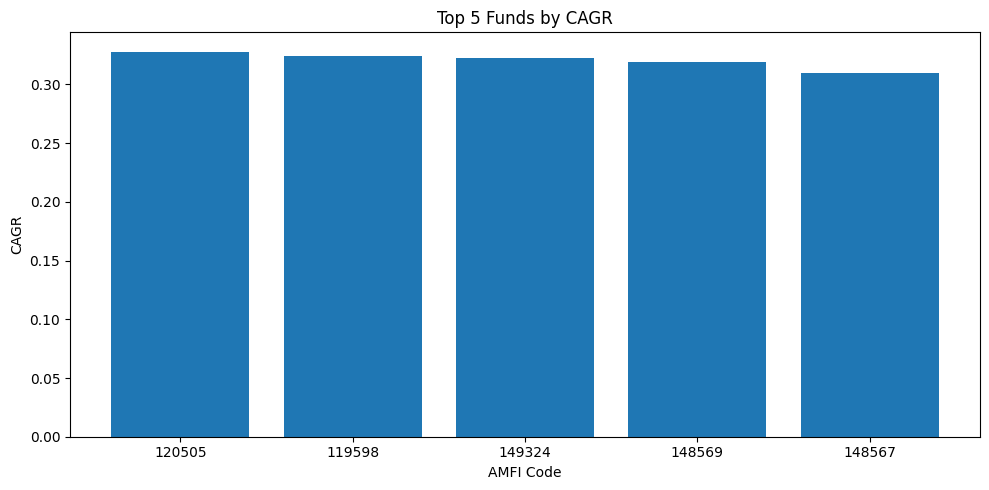

In [19]:
top5 = cagr_df.sort_values(
    "cagr",
    ascending=False
).head(5)

plt.figure(figsize=(10,5))

plt.bar(
    top5["amfi_code"].astype(str),
    top5["cagr"]
)

plt.title("Top 5 Funds by CAGR")

plt.xlabel("AMFI Code")
plt.ylabel("CAGR")

plt.tight_layout()

plt.savefig(
    "../reports/charts/benchmark_comparison.png"
)

plt.show()